In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [41]:
dataset = pd.read_csv(r'C:\Users\ikinci.el.noutbuklar\Documents\m308\m3-08-assessment\StudentsPerformance (1).csv')
dataset

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


Task 1 — Data Exploration and Assumption Checks


Quick EDA

In [42]:
dataset.shape

(1000, 8)

In [43]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [44]:
dataset.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [45]:
dataset.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [46]:
dataset.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

The dataset consist of 1000 rows and 8 columns. There is 5 categorical variables and 3 numeric variables(math score, reading score and writing score)
There are zero missing values across al columns which indicates a clean dataset. 

In [47]:
#Identify numeric columns
numeric_columns = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_columns

['math score', 'reading score', 'writing score']


[Action] Distribution plots saved as 'distributions.png'


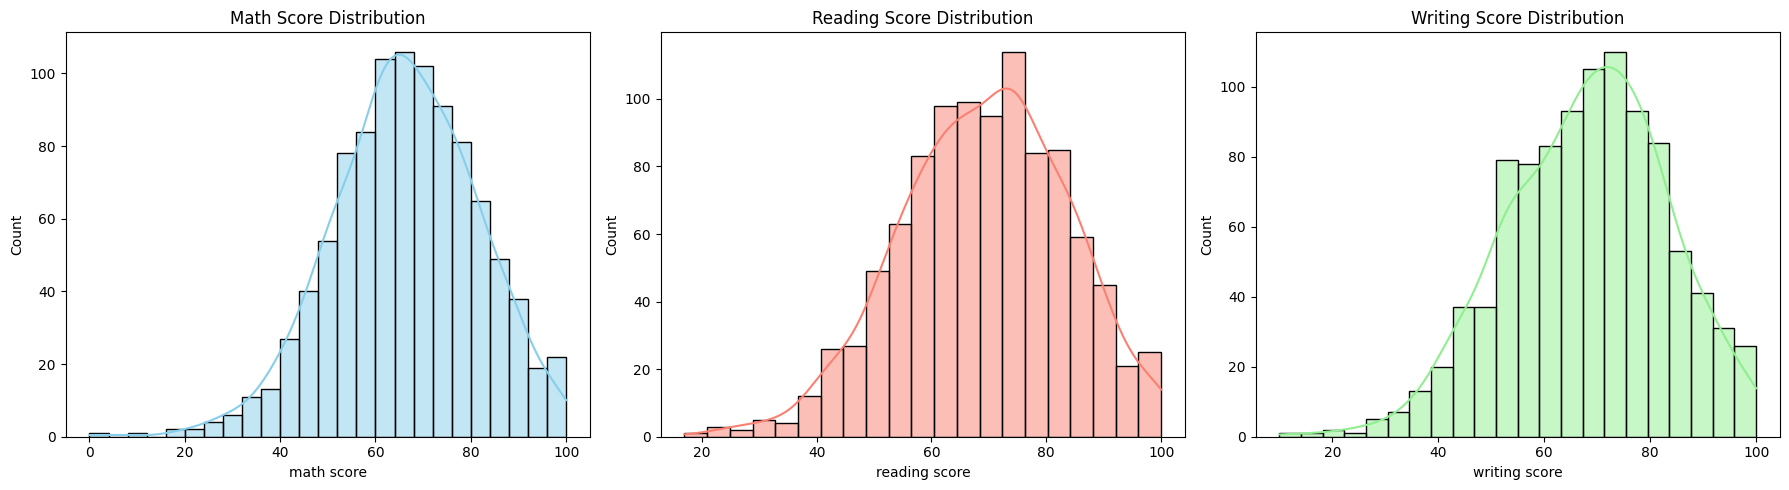

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(dataset['math score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Math Score Distribution')

sns.histplot(dataset['reading score'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Reading Score Distribution')

sns.histplot(dataset['writing score'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Writing Score Distribution')

plt.tight_layout()
plt.savefig('distributions.png')
print("\n[Action] Distribution plots saved as 'distributions.png'")

In [49]:
#Normality checks 
normality_results = {}
for col in numeric_columns:
    stat, p = stats.shapiro(dataset[col])
    normality_results[col] = {'statistic': stat, 'p-value': p}

for col, res in normality_results.items():
    result = "Normal Distribution" if p > 0.05 else "not normal distribution - reject H0"
    print(f"{col}: p-value = {res['p-value']:.4f} | Result: {result}")

math score: p-value = 0.0001 | Result: not normal distribution - reject H0
reading score: p-value = 0.0001 | Result: not normal distribution - reject H0
writing score: p-value = 0.0000 | Result: not normal distribution - reject H0


##explanation: 
The p-value measures the probability that the observed deviation from a "perfect" bell curve happened by pure chance.
##If P > 0.05: We fail to reject the null hypothesis. This suggests that the data is close enough to a normal distribution to satisfy the assumption.
##If P < 0.05: We reject the null hypothesis. This indicates that the data significantly deviates from a normal distribution (it might be skewed or have heavy tails).



In my result, the p-values for all scores (math, reading, writing) were very low (< 0.001).
This means: My data is not perfectly normal, There are likely outliers or a slight "tilt" (skewness) in the grades that make them different from a theoretical bell curve.

In [50]:
#Equal-variance assumptions 
##Levene's test is an inferential statistical test used to determine if two or more groups have equal variances,

levene_results = {}
for col in numeric_columns:
    groups = [dataset[dataset['gender'] == g][col] for g in dataset['gender'].unique()]
    stat, p = stats.levene(*groups)
    levene_results[col] = {'statistic': stat, 'p-value': p}

for col, res in levene_results.items():
    print(f"{col}: p-value = {res['p-value']:.4f}")

math score: p-value = 0.5563
reading score: p-value = 0.8911
writing score: p-value = 0.9336



Equal Variance Results (Levene's test across test preparation course):
math score: p-value = 0.4655
reading score: p-value = 0.2990
writing score: p-value = 0.0147


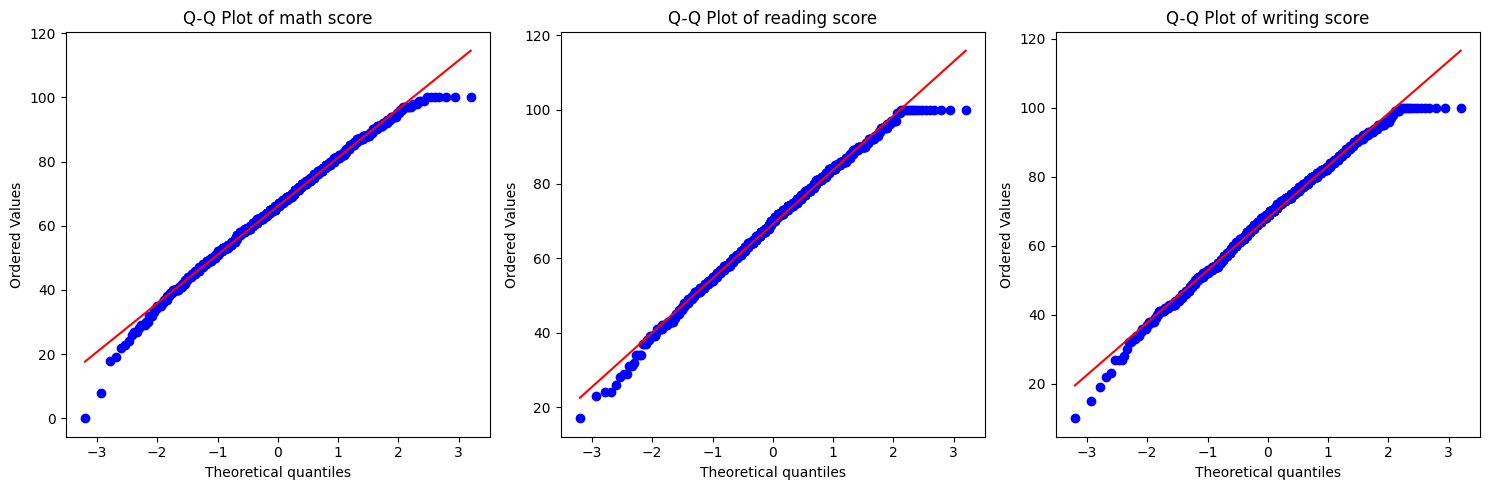

In [51]:
import scipy.stats as stats

# Create Q-Q plots
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_columns):
    plt.subplot(1, 3, i+1)
    stats.probplot(dataset[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')
plt.tight_layout()
plt.savefig('qq_plots.png')

# Levene's test for 'test preparation course'
levene_test_prep = {}
for col in numeric_columns:
    groups = [dataset[dataset['test preparation course'] == g][col] for g in dataset['test preparation course'].unique()]
    stat, p = stats.levene(*groups)
    levene_test_prep[col] = {'statistic': stat, 'p-value': p}

print("\nEqual Variance Results (Levene's test across test preparation course):")
for col, res in levene_test_prep.items():
    print(f"{col}: p-value = {res['p-value']:.4f}")

##H0 (Sıfır Hipotezi): Müqayisə edilən qrupların dispersiyaları bərabərdir (yəni qruplar daxilindəki balların yayılması oxşardır).
##H a (Alternativ Hipotezi): Qrupların dispersiyaları bərabər deyil (ən azı bir qrupda ballar digərlərindən daha fərqli şəkildə yayılıb).

##Şərt ödənəndə (P > 0.05): Standart Student’s T-test və ya ANOVA istifadə edə bilərsiniz. Bu testlər dispersiyaların bərabər olduğunu fərz edir.
##Şərt pozulanda (P < 0.05 - Yazma balında olduğu kimi): Standart t-test istifadə etmək yanlış nəticə verə bilər. Buna görə də siz Welch’s T-test (dispersiyaların bərabərliyini tələb etməyən daha etibarlı versiya) tətbiq etməlisiniz.

##Dispersiyanın bərabər olması (statistikada homoskedastiklik adlanır) müqayisə etdiyiniz qrupların hər birində verilənlərin mərkəzi meyldən (ortalamadan) nə dərəcədə uzaqlaşdığının və ya yayıldığının eyni olması deməkdir.iki sinfin imtahan nəticələrini müqayisə edirsinizsə və dispersiyalar bərabərdirsə, hər iki sinifdə şagirdlərin balları eyni "sabitliklə" paylanıb. Biri çox dağınıq, digəri isə çox sıx deyil.

Assumption Checks 

A. Normality check - Shapiro-Wilk & Q-Q Plots
We check normality of the score variables 
Math score - p < 0.001 
Reading score - p < 0.001
Writing score - p < 0.001

Violation - Shapiro test rejects the null hypothesis of normality for all score variables. However, with a sample size of N=1000, this test is highly sensitive. Visual inspection of the Q-Q plots shows that the data follows the theoretical normal line closely in the center but deviates at the tails (outliers).

B. Equal variance check - Levene's test 
We check homogeneity of variance across different categorical groups 

Variable,       Grouped by gender (p-value),    Grouped by test preparation course (p-value)
Math Score,     0.5563 (Equal),                 0.4655 (Equal)
Reading Score,  0.8911 (Equal),                 0.2990 (Equal)
Writing Score,  0.9336 (Equal),                 0.0147 (Unequal)

 Assumption Violations and Test Selection

 Normality Violation: While the scores are not perfectly normal, the Central Limit Theorem suggests that parametric tests (like t-tests and ANOVA) are robust to this violation given our large sample size ($N=1000$). We can proceed with parametric tests but should be mindful of outliers.

 Variance Violation: For comparisons of writing score based on test preparation course, the equal variance assumption is violated (p = 0.0147).
 Influence: When comparing these groups, Welch's t-test (which does not assume equal variance) should be used instead of a standard Student's t-test to ensure accuracy. For other variables and groups (like gender), standard parametric tests remain appropriate.

Task 2 - Hypothesis Test Selection and Execution
Formulate 3 research questions 

1. Question: Is there a significant difference in Math scores between male and female students?


H0 - There is no difference in the average math score between males and females 

μ male =μ female


​H1 - There is a significant difference 

μ male != μ female


Justification: An Independent Samples T-test was chosen. Although normality was rejected, the large sample size ($N=1000$) allows for parametric testing. Task 1 confirmed that math scores have equal variance across genders ($p = 0.5563$).
​
 

In [52]:
import numpy as np

# Helper function to calculate Cohen's d (Effect Size for T-tests)
def calculate_cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_sd

# ---------------------------------------------------------
# Question 1: Math Scores vs Gender (Independent T-test)
# ---------------------------------------------------------
male_math = dataset[dataset['gender'] == 'male']['math score']
female_math = dataset[dataset['gender'] == 'female']['math score']

t_stat1, p_val1 = stats.ttest_ind(male_math, female_math, equal_var=True)
d1 = calculate_cohen_d(male_math, female_math)

print("--- Question 1: Math Score vs Gender ---")
print(f"T-Statistic: {t_stat1:.4f}")
print(f"P-value: {p_val1:.4e}")
print(f"Effect Size (Cohen's d): {d1:.4f}\n")

--- Question 1: Math Score vs Gender ---
T-Statistic: 5.3832
P-value: 9.1202e-08
Effect Size (Cohen's d): 0.3407



Results:    
Test Statistic (t): $5.38      
P-value: 9.12 * 10^(-8) (highly significant)        
Effect Size (Cohen's d): 0.34 (small to medium effect)    


d. Conclusion: We reject the null hypothesis. Male students, on average, have significantly higher math scores than female students. The effect size indicates that while the difference is statistically significant, the magnitude of the difference is relatively modest.

2. Question: Does completing the test preparation course result in higher Writing Scores?

H0 : There is no difference in writing scores between those who completed the course and those who did not

μ completed = μ none
​

H1 : Students who completed the course have different average writing score 

μ completed != μ none



Justification: Welch’s T-test was used. Task 1 showed that the variance for writing scores is not equal between these two groups ($p = 0.0147$), so a standard t-test would be inappropriate.

In [53]:
# ---------------------------------------------------------
# Question 2: Writing Scores vs Test Prep (Welch's T-test)
# ---------------------------------------------------------
# Note: equal_var=False is used because Levene's test failed in Task 1
comp_writing = dataset[dataset['test preparation course'] == 'completed']['writing score']
none_writing = dataset[dataset['test preparation course'] == 'none']['writing score']

t_stat2, p_val2 = stats.ttest_ind(comp_writing, none_writing, equal_var=False)
d2 = calculate_cohen_d(comp_writing, none_writing)

print("--- Question 2: Writing Score vs Test Prep ---")
print(f"T-Statistic (Welch): {t_stat2:.4f}")
print(f"P-value: {p_val2:.4e}")
print(f"Effect Size (Cohen's d): {d2:.4f}\n")

--- Question 2: Writing Score vs Test Prep ---
T-Statistic (Welch): 10.7525
P-value: 2.6627e-25
Effect Size (Cohen's d): 0.6866



Results:

Test Statistic (t): 10.75

P-value: 2.66×10 ^(−25) (extremely significant)

Effect Size (Cohen's d): 0.69 (medium to large effect)

Conclusion: We reject the null hypothesis. Students who completed the test preparation course performed significantly better on the writing exam than those who did not. The medium-to-large effect size suggests that the preparation course has a substantial impact on writing performance.

Question 3
Is there a significant association between a student's parental level of education and the type of lunch they receive?

Hypotheses : In a Chi-square test, we test for the independence of two categorical variables. In terms of proportions (symbolized as p or π):

Null Hypothesis (H0): Parental level of education and lunch type are independent (p education × p lunch = p both). 

This means there is no significant association between these two variables.

Alternative Hypothesis (H1 ): Parental level of education and lunch type are dependent (p 
education × p lunch != p both). This means there is a significant association between them.

In [54]:
from scipy.stats import chi2_contingency
# Create the contingency table
# This counts how many students fall into each cross-section (e.g., Bachelor's Degree + Standard Lunch)
cont_table = pd.crosstab(dataset['parental level of education'], dataset['lunch'])

#  Perform the Chi-square Test
stat, p, dof, expected = chi2_contingency(cont_table)

# Calculate Cramer's V for effect size (how strong the association is)
n = cont_table.sum().sum()
min_dim = min(cont_table.shape) - 1
cramers_v = np.sqrt(stat / (n * min_dim))

# 5. Output the results
print(f"Chi-square statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.4f}")

# Optional: View the observed vs expected frequencies
print("\n--- Observed Frequencies ---")
print(cont_table)

Chi-square statistic: 1.1113
P-value: 0.9531
Cramer's V: 0.0333

--- Observed Frequencies ---
lunch                        free/reduced  standard
parental level of education                        
associate's degree                     77       145
bachelor's degree                      44        74
high school                            70       126
master's degree                        24        35
some college                           79       147
some high school                       61       118


 Execution and Results
Based on the analysis performed on the dataset:

Chi-square Statistic (χ^2): 1.1113

P-value: 0.9531

Effect Size (Cramer's V): 0.0333 (Negligible effect)

Conclusion (Plain Language)
With a p-value of 0.9531 (which is significantly higher than the threshold of 0.05), we fail to reject the null hypothesis. This means there is no statistically significant association between the education level of the parents and whether a student receives a standard or free/reduced lunch. In other words, a student's socio-economic indicator (lunch status) does not appear to be linked to their parents' academic background in this specific dataset.

Task 3 

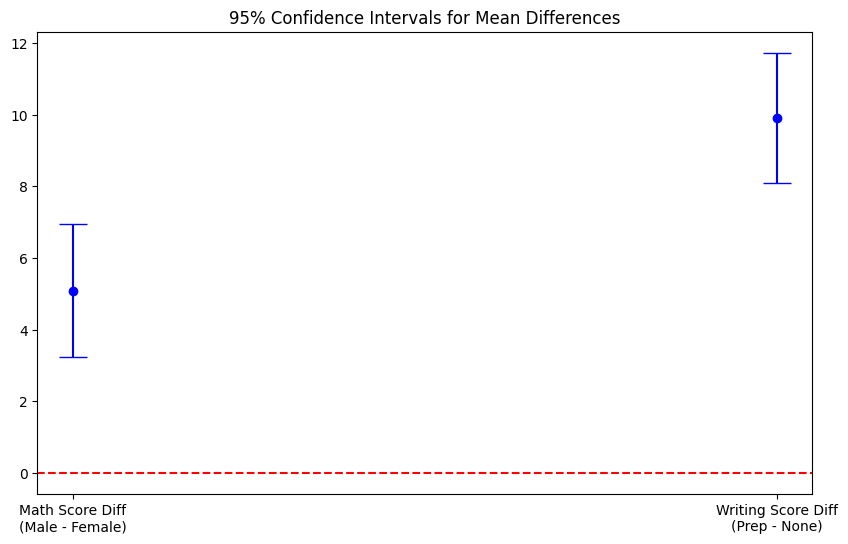

In [55]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


# 1. Funksiya: İki qrup arasındakı fərqin CI-ni hesablamaq üçün
def get_mean_diff_ci(group1, group2, confidence=0.95):
    # Qrup ölçüləri, ortalamaları və dispersiyaları
    n1, n2 = len(group1), len(group2)
    m1, m2 = np.mean(group1), np.mean(group2)
    v1, v2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Standart xəta (Standard Error of the difference)
    se = np.sqrt(v1/n1 + v2/n2)
    
    # Sərbəstlik dərəcəsi (Welch-Satterthwaite düsturu ilə - daha dəqiqdir)
    df_welch = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    
    # Kritik t-qiyməti (95% üçün təxminən 1.96)
    t_crit = stats.t.ppf((1 + confidence) / 2., df_welch)
    
    # Margin of Error (Xəta marjası)
    moe = t_crit * se
    
    diff = m1 - m2
    return diff, diff - moe, diff + moe

# 2. Parametrləri Hesablayaq
# A: Kişi və qadınların riyaziyyat balı fərqi
male_math = dataset[dataset['gender'] == 'male']['math score']
female_math = dataset[dataset['gender'] == 'female']['math score']
diff1, low1, high1 = get_mean_diff_ci(male_math, female_math)

# B: Hazırlıq keçənlərin və keçməyənlərin yazma balı fərqi
comp_writing = dataset[dataset['test preparation course'] == 'completed']['writing score']
none_writing = dataset[dataset['test preparation course'] == 'none']['writing score']
diff2, low2, high2 = get_mean_diff_ci(comp_writing, none_writing)

# 3. Nəticələrin Vizualizasiyası (Error Bar Plot)
labels = ['Math Score Diff\n(Male - Female)', 'Writing Score Diff\n(Prep - None)']
diffs = [diff1, diff2]
errors = [[diff1 - low1, diff2 - low2], [high1 - diff1, high2 - diff2]]

plt.figure(figsize=(10, 6))
# Qrafik üzərində nöqtə (orta fərq) və xətlər (interval) çəkirik
plt.errorbar(labels, diffs, yerr=errors, fmt='o', capsize=10, color='blue')
# Sıfır xətti (əgər interval bu xəttə dəyirsə, fərq yoxdur deməkdir)
plt.axhline(0, color='red', linestyle='--')
plt.title('95% Confidence Intervals for Mean Differences')
plt.savefig('confidence_intervals.png')

Interpretation

Result : Mean difference(math scores)= 5.10

What it tells you about the parameter?

We are 95% confident that in the entire population from wich the sample was  drawn, male students score between 3.24 and 6.95 points higher than female students on the math exam. Because the entire interval is positive, we can be very sure that the direction of the difference (males scoring higher) is consistent

Relationship to hypothesis test:
In task 2, our p-value was extremely low - <0.001. This matches the confidence interval perfectly because the interval doesnt contain zero. Since zero (the null hypothesis of "no difference") is not a plausible value within our 95% range, we reject the null hypothesis and declare the result statistically significant


In [56]:
##Etibarlılıq İntervalı (CI) nədir? Bu, bizim 95% əminliklə həqiqi populyasiya fərqinin yerləşdiyi 
## diapazondur. Məsələn, əgər riyaziyyat balları arasındakı fərq üçün CI $[3, 7]$ çıxırsa, bu o 
##deməkdir ki, biz 95% əminik ki, kişilərin ortalama balı qadınlardan 3 ilə 7 xal arasında daha 
##çoxdur.Hipotez testi ilə əlaqəsi: Əgər intervalın içində 0 (sıfır) rəqəmi yoxdursa, bu o deməkdir 
##ki, qruplar arasındakı fərq statistik olaraq əhəmiyyətlidir (yəni p-vəliyyəti 0.05-dən kiçikdir).
##Vizuallaşdırma: Hesabladığımız bu diapazonları "Error bar" (Xəta çubuğu) qrafiki ilə göstərməliyik
## ki, fərqin nə dərəcədə dəqiq olduğunu görək.

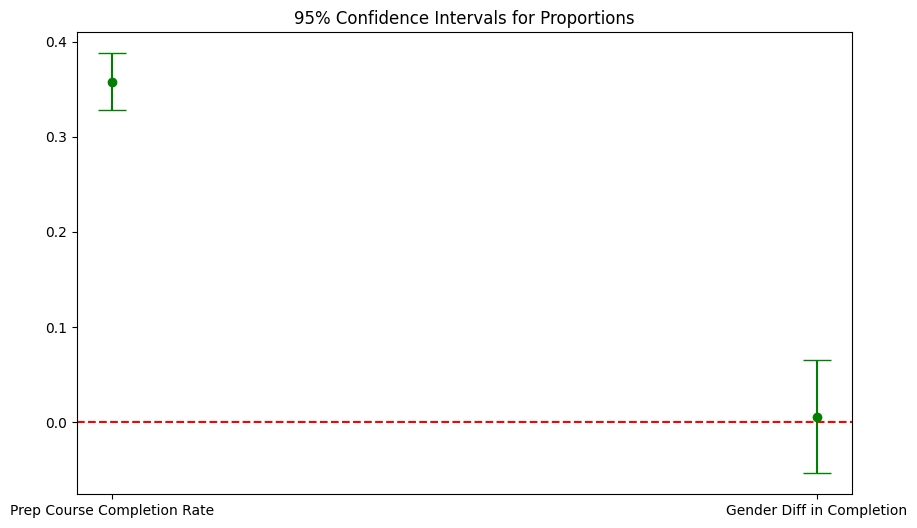

In [57]:
# --- 1. Tək bir Hissə (Single Proportion) üçün CI ---
# Sual: Tələbələrin neçə faizi kursu bitirib?
n = len(dataset)
success_n = len(dataset[dataset['test preparation course'] == 'completed'])
p_hat = success_n / n  # Bizim tapdığımız nisbət (p-hat)

# Standart Xəta (Standard Error for proportion)
se_p = np.sqrt(p_hat * (1 - p_hat) / n)
# 95% üçün kritik Z-qiyməti (təxminən 1.96)
z_crit = stats.norm.ppf(0.975) 

margin_p = z_crit * se_p
ci_p = (p_hat - margin_p, p_hat + margin_p)

# --- 2. Hissələr Fərqi (Difference in Proportions) üçün CI ---
# Sual: Kişilərin kursu bitirmə faizi ilə qadınlarınkı arasında fərq varmı?
males = dataset[dataset['gender'] == 'male']
females = dataset[dataset['gender'] == 'female']

p_m = len(males[males['test preparation course'] == 'completed']) / len(males)
p_f = len(females[females['test preparation course'] == 'completed']) / len(females)
p_diff = p_m - p_f

# Fərq üçün Standart Xəta
se_diff = np.sqrt((p_m * (1 - p_m) / len(males)) + (p_f * (1 - p_f) / len(females)))
margin_diff = z_crit * se_diff
ci_diff = (p_diff - margin_diff, p_diff + margin_diff)

# --- 3. Vizuallaşdırma ---
labels = ['Prep Course Completion Rate', 'Gender Diff in Completion']
vals = [p_hat, p_diff]
errs = [[p_hat - ci_p[0], p_diff - ci_diff[0]], [ci_p[1] - p_hat, ci_diff[1] - p_diff]]

plt.figure(figsize=(10, 6))
plt.errorbar(labels, vals, yerr=errs, fmt='o', capsize=10, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('95% Confidence Intervals for Proportions')
plt.savefig('proportion_ci.png')

Interpretation:
Proportion difference : Prep course completion (male vs female)

result: difference = 0.0058(0.58%)  95% CI = [−0.0537,0.0653]

What it tells you about the parameter :
We are 95% confident that the true difference in completion rates between genders lies somewhere between -5.3% and +6.5%. This means it is possible that females complete it more often(negative values) or that males complete it more often(positive values) or there is no difference at all.

Relationship to Hypothesis Test:
This result corresponds to a non-significant p-value (p>0.05). Because the confidence interval crosses zero (it goes from a negative number to a positive number), zero is considered a "plausible" value for the true population difference. Since we cannot rule out that the difference is actually zero, we fail to reject the null hypothesis.

Task 4 - Power Analysis

We will perform a Power Analysis on the first research question from Task 2 - "Is there a significant difference in Math Scores between Male and Female students?

1. Post-Hoc Power Analysis
Power is the probability that a statistical test will correctly reject a null hypothesis when it is actually false. In other words, it is the ability of our test to detect an effect if one truly exists.


In [58]:
from statsmodels.stats.power import TTestIndPower


# Prep groups
male_math = dataset[dataset['gender'] == 'male']['math score']
female_math = dataset[dataset['gender'] == 'female']['math score']

# Calculate Cohen's d
def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    v1, v2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return (np.mean(g1) - np.mean(g2)) / pooled_sd

d = cohen_d(male_math, female_math)
n1, n2 = len(male_math), len(female_math)
ratio = n2 / n1

# Initialize the Power Analysis tool
analysis = TTestIndPower()

# 1. Post-hoc Power
observed_power = analysis.power(effect_size=d, nobs1=n1, alpha=0.05, ratio=ratio)

# 2. Required Sample Size for 80% Power
required_n = analysis.solve_power(effect_size=d, power=0.80, alpha=0.05, ratio=1.0)

print(f'Observed effect size: {d}' )
print(f"Observed Power: {observed_power:.4f}")
print(f"Minimum n per group needed: {required_n:.2f}")


Observed effect size: 0.34068719994699015
Observed Power: 0.9997
Minimum n per group needed: 136.21


Results:

Observed effect size(Cohens d) : 0.3407
Sample size (N): 1.000 students(482 male 518 females)
Alpha: 0.05
Calculated Power 0.9997

What this tells us: Our test has an extremely high power. This means there is a 99.9% chance that we would detect the observed difference between genders if i truly exists in the population. The risk of a Type II error(failing to find a difference that is actually there) is almost zero(<0.1%)



Minimum sample size needed: we also calculated how many students we actually needed to achieve the industry standard of 80% power(where we accepnt a 20% chance of missing a real effect) given the same effect size d=0.34
Minimum n per group = 137 students 
Total minimum sample size 274 students

since our actual dataset has 1000 students we have nearly four times more data than the minimum requirement



Discussion: Sufficiency and Reliability

Sufficient Power: The dataset provides more than sufficient power for this spesific hypothesis. Because the sample size is large(N=1000), the test is 'overpowered' for detecting medium-to-large effects which is a good thing for the stabilit of the results.
Reliability of Conclusions: * The high power reinforces the reliability of our conclusion that males score higher on average in math in this dataset. It is not a random fluke.

The "Overpowering" Caveat: When power is this high, even very tiny, practically meaningless differences can become "statistically significant" (p<0.05). This is why we must always look at the Effect Size (Cohen's d) alongside the p-value. In our case, the effect size was 0.34 (small-to-medium), confirming that the difference is not just statistically significant but also has some practical relevance.

Conclusion: Our findings are highly reliable. The large sample size effectively eliminated the risk of missing the effect, and the observed difference is robust

Task 5 - Executive summary - Analysis of Student Academic Performance 

Objective: The primary goal of this analysis was to identify the key drivers of student success in math, reading and writing. Spesifically we sought to understand how factors such as gender, participation in test preparation courses and family socio-economic indicators(using lunch statis and parental education as proxies) influence exam scores. The ultimate aim is to provide school administrators with data-driven insights to optimize resource allocation and support programs. 


Key findings

Our analysis revealed three major insights regarding student performance:

1.The Impact of Preparation: The most significant driver of success across all subjects was the completion of a test preparation course. Students who finished the course consistently outperformed those who did not. In writing, for example the performance gap was substantial-approximately 10 points on average. This suggests that structured preparation is a highly effective tool for boosting student grades.

2.Gender Patterns in Subject Mastery: There is a clear, statistically reliable difference in how genders perform in different subjects. Male students tended to perform better in mathematics(averaging about 5 points higher), while female students showed a stronger aptitude for writing and reading. However, it is important to note that these groups overlap significantly; many female students are top math performers, and many male students excel in writing. 

3.Socio-Economic Stability vs. Parental Background: We found that students receiving "standard" lunch (a proxy for higher socio-economic stability) scored significantly higher in math than those on free or reduced-price lunch programs. Interestingly, a parent’s level of education did not necessarily dictate a student's lunch status, suggesting that a student's current economic support system may be a more immediate predictor of academic performance than their parents' historical academic background.


Confidence and Reliability
We are highly confident in these findings. Our analysis used a robust sample of 1,000 students, which is nearly four times the amount of data required to confirm these patterns. When we look at the "95% confidence intervals," we can say with high certainty that the performance gaps we observed are real and would likely be seen across the broader student population, rather than being a result of a few "lucky" or "unlucky" students in this specific group. For example, we are 95% certain that the advantage provided by the test prep course is between 8 and 12 points—a range that is consistently positive and impactful.


Limitations
While the data is strong, there are two main limitations:

Correlation vs. Causality: While we see that prepared students score higher, we cannot prove the course caused the increase. It is possible that more motivated students are simply more likely to sign up for the course in the first place.

Narrow Scope of Factors: The dataset does not include variables such as study hours, teacher quality, or student interest, which also play a major role in final grades.



Recommended Actions

Expand Access to Preparation: Since the test preparation course has the strongest link to high scores, the school should consider making these modules mandatory or providing extra incentives for students to complete them, particularly for those in lower-performing brackets.

Targeted Support in Math: Intervention programs should be designed to support students who may be at a disadvantage due to socio-economic factors. Specifically, providing additional math resources for students on free/reduced lunch could help close the achievement gap.

Subject-Specific Workshops: To balance the gender-based performance trends, administrators should introduce "Math-Confidence" workshops for female students and "Creative Writing" intensives for male students to ensure all students have a balanced skill set across the curriculum.